In [1]:
import numpy as np

In [12]:

from sklearn import datasets
digits = datasets.load_digits()


In [4]:
all_images = digits.images
all_labels = digits.target

Text(0.5, 1.0, 'Label: 4')

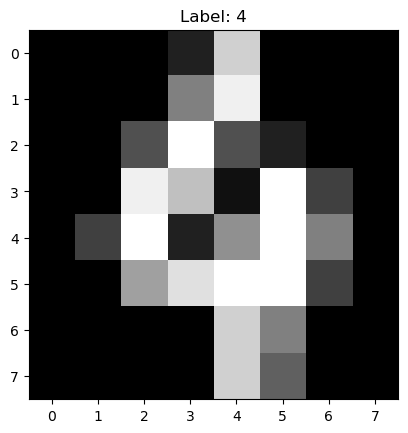

In [11]:
import matplotlib.pyplot as plt
img_number = 100
test_input = all_images[img_number]
test_target = all_labels[img_number]

plt.imshow(test_input, cmap='gray')
plt.title(f'Label: {test_target}')

In [18]:
all_images[5].max()

np.float64(16.0)

In [ ]:
64 x 8 x 8 x 10

In [19]:
import torch

In [37]:
model = torch.nn.Sequential(
    torch.nn.Linear(64,8),
    torch.nn.ReLU(),
    torch.nn.Linear(8,10)
)

In [38]:
print(model)

Sequential(
  (0): Linear(in_features=64, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=10, bias=True)
)


In [40]:
lost_fun = torch.nn.CrossEntropyLoss() # this is for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # this is for updating the weights of the model
total_images = len(all_images)
for img_number, (img, label) in enumerate(zip(all_images, all_labels)):
    if img_number % 100 == 0:
        print(f'Image number: {img_number}/{total_images}')
    
    img_tensor = torch.tensor(img, dtype=torch.float32)
    img_extend = img_tensor.flatten()
    X = img_extend.float() / 16.0
    y = label

    for epoch in range(10):
        y_pred = model(X)
        loss = lost_fun(y_pred.unsqueeze(0), torch.tensor([y]))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()








    

Image number: 0/1797
Image number: 100/1797
Image number: 200/1797
Image number: 300/1797
Image number: 400/1797
Image number: 500/1797
Image number: 600/1797
Image number: 700/1797
Image number: 800/1797
Image number: 900/1797
Image number: 1000/1797
Image number: 1100/1797
Image number: 1200/1797
Image number: 1300/1797
Image number: 1400/1797
Image number: 1500/1797
Image number: 1600/1797
Image number: 1700/1797


8


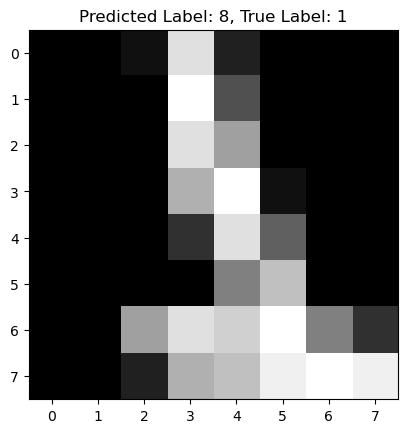

In [44]:
img_number = 1000

sample_image = all_images[img_number]
img_torch = torch.tensor(sample_image, dtype=torch.float32)
img_extend = img_torch.flatten()
sample_image_tensor = img_extend.float() / 16.0

predict_output = model(sample_image_tensor)
predicted_label = torch.argmax(predict_output).item()


print(predicted_label)

plt.imshow(sample_image, cmap='gray')
plt.title(f'Predicted Label: {predicted_label}, True Label: {all_labels[img_number]}')
plt.show()